# CE49X Lab 3: Where Should You Open a Gas Station in Istanbul?
## A Traffic-Based Site Selection Analysis

**Instructor:** Dr. Eyuphan Koc  
**Department of Civil Engineering, Bogazici University**  
**Semester:** Spring 2026

---

## Background

A fuel distribution company is planning to open **3 new gas stations** in Istanbul. They have hired you as a consulting engineer to identify the best locations based on **traffic patterns only**.

We provide a starter traffic dataset covering one week of hourly sensor readings across Istanbul (`istanbul_traffic_week.csv` + `sensor_coords.csv`). However, **you are free to use any traffic data source you prefer** — you may use the provided dataset, supplement it with additional data, or replace it entirely. Some options:

- **Provided dataset:** `istanbul_traffic_week.csv` (75,000 records from ~2,400 sensors, one week in October 2024) + `sensor_coords.csv` (sensor coordinates)
- **IBB Open Data Portal:** Istanbul Metropolitan Municipality publishes live and historical traffic data at [data.ibb.gov.tr](https://data.ibb.gov.tr). You can query their APIs for broader coverage or more recent data.
- **Other sources:** Any publicly available traffic dataset for Istanbul is acceptable (e.g., Google Maps traffic layer, TomTom Traffic Index, or any other API/dataset you can find).

**Whatever data you use, clearly document your source and how you obtained it.**

Your job is to:
1. **Analyze traffic data** to understand where high-volume, low-speed (stop-and-go) traffic occurs — these are the locations where drivers are most likely to stop for fuel.
2. **Collect existing gas station data** for Istanbul to identify areas that are underserved.
3. **Propose 3 optimal locations** for new gas stations, supported by data and visualizations.

## Provided Data (Optional Starting Point)

The following files are included in the course repository. You may use them as-is, supplement them with additional data, or use a completely different traffic source.

### `istanbul_traffic_week.csv`

| Column | Description |
|--------|-------------|
| `DATE_TIME` | Timestamp of the observation (hourly, one week in October 2024) |
| `LATITUDE` | Latitude of the traffic sensor |
| `LONGITUDE` | Longitude of the traffic sensor |
| `GEOHASH` | Geohash code identifying the sensor location |
| `MINIMUM_SPEED` | Minimum observed speed (km/h) during the hour |
| `MAXIMUM_SPEED` | Maximum observed speed (km/h) during the hour |
| `AVERAGE_SPEED` | Average speed (km/h) during the hour |
| `NUMBER_OF_VEHICLES` | Total vehicle count during the hour |

### `sensor_coords.csv`

| Column | Description |
|--------|-------------|
| `node_id` | Geohash code (matches `GEOHASH` in the traffic data) |
| `lat` | Latitude of the sensor |
| `long` | Longitude of the sensor |

If you use a different data source, include an equivalent data description in your notebook.

## Deliverables

Your notebook must include the following:

### 1. Traffic Data — Source & Exploration
- **Document your traffic data source.** If you use the provided dataset, state that. If you use IBB APIs, another source, or a combination, describe what you collected and how.
- Load and explore your traffic data
- Compute per-location summary statistics: **mean daily vehicle count**, **mean speed**, **peak-hour vehicle count** (adapt as needed to your data)
- Identify temporal patterns: how does traffic volume vary by **hour of day** and **day of week**?
- Identify the **top 20 highest-traffic locations** by total vehicle count

### 2. Traffic-Based Demand Scoring
- Design a **demand score** for each location that captures how attractive it is for a gas station. Your score should consider at least:
  - **High vehicle volume** (more cars = more potential customers)
  - **Low average speed** (slow/congested traffic = drivers more willing to stop)
  - **Consistency** across hours and days (a location busy only at 3 AM is less useful)
- Clearly explain and justify the formula or method you use
- Rank all locations by your demand score

### 3. Existing Gas Station Data (you must collect this)
- Collect the locations of **existing gas stations across Istanbul**
- You must have **at least 200 stations** with latitude/longitude coordinates
- **Document your data source and collection method** in a markdown cell
- For each of your high-demand locations, compute the **distance to the nearest existing gas station**

### 4. Site Selection
- Combine your demand score with existing station proximity to identify **underserved, high-demand areas**
- A great location has: high demand score AND is far from existing gas stations
- Propose **exactly 3 locations** for new gas stations
- For each proposed location, report:
  - Coordinates (latitude, longitude)
  - The neighborhood/district name
  - Your demand score
  - Distance to the nearest existing gas station
  - A brief justification (2-3 sentences)

### 5. Visualizations
- Create **at least three plots/maps**. Suggested visualizations (or propose your own):
  - A heatmap or scatter map of demand scores across Istanbul
  - A map showing existing gas stations and your 3 proposed locations
  - A bar chart or time-series plot showing traffic patterns at your proposed locations
- All plots must be publication-quality: labeled axes, title, legend, grid where appropriate
- Interactive maps (e.g., folium) are encouraged but not required

### 6. Discussion
- Write a short discussion (2-3 paragraphs) addressing:
  - Why did you choose these 3 locations over other candidates?
  - What **limitations** does a traffic-only analysis have? What other factors would a real site selection study consider (e.g., land cost, zoning, competition, road type)?
  - If you had access to one additional dataset, what would it be and how would it improve your analysis?

## Hints

- **Haversine formula** for distance between two GPS coordinates:

$$d = 2R \arcsin\left(\sqrt{\sin^2\left(\frac{\Delta\phi}{2}\right) + \cos(\phi_1)\cos(\phi_2)\sin^2\left(\frac{\Delta\lambda}{2}\right)}\right)$$

  where $R = 6{,}371$ km is the Earth's radius, $\phi$ is latitude, and $\lambda$ is longitude (in radians).

- **Normalizing scores:** When combining metrics with different scales (e.g., vehicle count vs. speed), normalize each to a 0-1 range first:

$$x_{\text{norm}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

- If using the provided dataset, the `GEOHASH` column can be used to join the traffic data with `sensor_coords.csv` via the `node_id` column.

- Think about whether **weekday** vs. **weekend** traffic patterns matter for a gas station business.

## Grading

| Component | Weight |
|-----------|--------|
| Traffic data exploration (statistics, temporal patterns) | 15% |
| Demand scoring (methodology, justification) | 20% |
| Existing station data (collection, completeness, documentation) | 20% |
| Site selection (3 locations with supporting evidence) | 20% |
| Visualizations (clarity, quality, informativeness) | 15% |
| Discussion (limitations, critical thinking) | 10% |

## Submission

1. Complete your work in **this notebook** on your own fork of the course repository.
2. Make sure your notebook **runs top-to-bottom without errors** before submitting.
3. Commit and push your completed notebook to your fork.
4. We will grade directly from your fork — there is no separate upload. Make sure your latest work is pushed before the deadline.

---
## Your Work Starts Here

## Data Source Note (Sensor Coordinates)

`sensor_coords.csv` was generated by combining the local Week 3 traffic file with additional public web data.

### Primary data sources used
- **IBB Open Data Portal (official): Hourly Traffic Density Data Set**  
  https://data.ibb.gov.tr/dataset/3ee6d744-5da2-40c8-9cd6-0e3e41f1928f
- Local course file: `Week03_NumPy_Pandas/istanbul_traffic_week.csv`

### Additional web data included
To enrich coverage, I added sensor points from multiple IBB monthly web CSV snapshots across different years:
- 202001, 202101, 202201, 202301, 202401, 202501

### Method
- Extracted unique `GEOHASH` + (`LATITUDE`, `LONGITUDE`) from all sources above.
- Converted to a unified coordinate table with columns:
  - `sensor_id`
  - `latitude`
  - `longitude`
- Final merged table size: **2471 sensors** (vs. 2439 from the local week file alone).

### Why this source choice
- I evaluated other public options (e.g., TomTom APIs, Kaggle mirrors).
- TomTom requires API access/credits and does not directly provide the same open geohash sensor table used in this lab setup.
- Kaggle examples are mostly re-shared IBB traffic files rather than a more authoritative source.

This approach keeps IDs compatible with the traffic dataset while adding validated sensor coverage from public web data.

In [79]:
# Load traffic data and sensor coordinate lookup table (robust path resolution)
import pandas as pd
from pathlib import Path


def resolve_lab_paths():
    """Find Week03/lab files regardless of current working directory."""
    cwd = Path.cwd().resolve()
    search_roots = [cwd] + list(cwd.parents)

    for root in search_roots:
        week_candidate = root / "Week03_NumPy_Pandas"
        lab_candidate = week_candidate / "lab"
        traffic_candidate = week_candidate / "istanbul_traffic_week.csv"
        sensor_candidate = lab_candidate / "sensor_coords.csv"

        if traffic_candidate.exists() and sensor_candidate.exists():
            return week_candidate, lab_candidate, traffic_candidate, sensor_candidate

    raise FileNotFoundError(
        "Could not locate Week03 data files. Expected: "
        "Week03_NumPy_Pandas/istanbul_traffic_week.csv and "
        "Week03_NumPy_Pandas/lab/sensor_coords.csv"
    )


week_dir, lab_dir, traffic_path, sensor_path = resolve_lab_paths()

traffic_df = pd.read_csv(traffic_path)
sensor_df = pd.read_csv(sensor_path)

print("Resolved week_dir:", week_dir)
print("Resolved lab_dir:", lab_dir)
print(f"Traffic rows: {len(traffic_df):,}")
print(f"Sensor rows: {len(sensor_df):,}")
print(sensor_df.head())

Resolved week_dir: C:\Users\alp5k\CE49X\Week03_NumPy_Pandas
Resolved lab_dir: C:\Users\alp5k\CE49X\Week03_NumPy_Pandas\lab
Traffic rows: 75,000
Sensor rows: 2,471
  sensor_id   latitude  longitude
0    sx7chk  40.981750  27.965698
1    sx7chm  40.987244  27.965698
2    sx7cht  40.987244  27.976685
3    sx7chw  40.992737  27.976685
4    sx7chx  40.998230  27.976685


## Existing Gas Station Data (Public Web Source)

For existing station locations, this notebook uses a **public OpenStreetMap dataset** queried through the **Overpass API**.

- Source: OpenStreetMap contributors (ODbL), accessed via `https://overpass-api.de/api/interpreter`
- Query filter: `amenity = fuel`
- Geographic scope: Istanbul bounding box (`lat: 40.80 to 41.35`, `lon: 28.40 to 29.80`)
- Output file: `existing_gas_stations_osm.csv`

This provides a large set of real station coordinates for nearest-station distance analysis.

In [80]:
# Load existing gas station locations from OpenStreetMap (Overpass API export)
stations_path = lab_dir / "existing_gas_stations_osm.csv"
if not stations_path.exists():
    raise FileNotFoundError(
        f"Missing file: {stations_path}. Run the data collection step first "
        "or place existing_gas_stations_osm.csv into the lab folder."
    )

stations_df = pd.read_csv(stations_path)

print(f"Existing stations rows: {len(stations_df):,}")
print(stations_df[['station_id', 'name', 'latitude', 'longitude']].head())

Existing stations rows: 796
       station_id          name   latitude  longitude
0  node/266753132       Aytemiz  40.896837  29.224951
1  node/269367213          Opet  41.026080  28.979786
2  node/278335431  Petrol Ofisi  41.028838  29.017440
3  node/288789439  Petrol Ofisi  41.114194  29.059922
4  node/446288239  Class Petrol  41.000190  28.800738


## 1) Traffic Data Exploration (Step by Step)

In this section, we prepare the traffic data and compute the core exploratory statistics requested in the assignment:

1. Parse timestamps and create time-based features (`hour`, `day_of_week`, `date`)
2. Build per-location summary statistics
3. Identify top-traffic locations
4. Visualize temporal patterns by hour and day

In [81]:
# Step 1: basic preprocessing
import numpy as np
import matplotlib.pyplot as plt

traffic_df = traffic_df.copy()
traffic_df['DATE_TIME'] = pd.to_datetime(traffic_df['DATE_TIME'])
traffic_df['hour'] = traffic_df['DATE_TIME'].dt.hour
traffic_df['day_of_week'] = traffic_df['DATE_TIME'].dt.day_name()
traffic_df['date'] = traffic_df['DATE_TIME'].dt.date

# Use GEOHASH as the sensor key
traffic_df['sensor_id'] = traffic_df['GEOHASH']

print('Traffic date range:', traffic_df['DATE_TIME'].min(), 'to', traffic_df['DATE_TIME'].max())
print('Unique sensors in traffic data:', traffic_df['sensor_id'].nunique())
traffic_df.head()

Traffic date range: 2024-10-01 00:00:00 to 2024-10-07 23:00:00
Unique sensors in traffic data: 2439


,DATE_TIME,LATITUDE,LONGITUDE,GEOHASH,MINIMUM_SPEED,MAXIMUM_SPEED,AVERAGE_SPEED,NUMBER_OF_VEHICLES,hour,day_of_week,date,sensor_id
0,2024-10-01,41.119080,29.042358,sxk9uv,49,67,59,3,0,Tuesday,2024-10-01,sxk9uv
1,2024-10-01,41.064148,29.064331,sxk9t7,8,48,27,6,0,Tuesday,2024-10-01,sxk9t7
2,2024-10-01,41.091614,29.031372,sxk9u8,10,149,77,180,0,Tuesday,2024-10-01,sxk9u8
3,2024-10-01,41.108093,29.086304,sxk9vg,2,60,39,12,0,Tuesday,2024-10-01,sxk9vg
4,2024-10-01,41.113586,29.042358,sxk9uu,7,88,46,16,0,Tuesday,2024-10-01,sxk9uu


In [82]:
# Step 2: per-location summary statistics
# - mean daily vehicle count
# - mean speed
# - peak-hour vehicle count

daily_sensor = (
    traffic_df
    .groupby(['sensor_id', 'date'], as_index=False)['NUMBER_OF_VEHICLES']
    .sum()
    .rename(columns={'NUMBER_OF_VEHICLES': 'daily_vehicles'})
)

mean_daily_by_sensor = (
    daily_sensor
    .groupby('sensor_id', as_index=False)['daily_vehicles']
    .mean()
    .rename(columns={'daily_vehicles': 'mean_daily_vehicle_count'})
)

mean_speed_by_sensor = (
    traffic_df
    .groupby('sensor_id', as_index=False)['AVERAGE_SPEED']
    .mean()
    .rename(columns={'AVERAGE_SPEED': 'mean_speed'})
)

peak_hour_by_sensor = (
    traffic_df
    .groupby('sensor_id', as_index=False)['NUMBER_OF_VEHICLES']
    .max()
    .rename(columns={'NUMBER_OF_VEHICLES': 'peak_hour_vehicle_count'})
)

total_vehicles_by_sensor = (
    traffic_df
    .groupby('sensor_id', as_index=False)['NUMBER_OF_VEHICLES']
    .sum()
    .rename(columns={'NUMBER_OF_VEHICLES': 'total_vehicle_count'})
)

location_stats = (
    mean_daily_by_sensor
    .merge(mean_speed_by_sensor, on='sensor_id', how='inner')
    .merge(peak_hour_by_sensor, on='sensor_id', how='inner')
    .merge(total_vehicles_by_sensor, on='sensor_id', how='inner')
)

top20_locations = (
    location_stats
    .sort_values('total_vehicle_count', ascending=False)
    .head(20)
    .reset_index(drop=True)
)

print('Per-location summary table shape:', location_stats.shape)
print('\nTop 20 highest-traffic locations (by total vehicle count):')
top20_locations[['sensor_id', 'total_vehicle_count', 'mean_daily_vehicle_count', 'mean_speed', 'peak_hour_vehicle_count']]

Per-location summary table shape: (2439, 5)

Top 20 highest-traffic locations (by total vehicle count):


,sensor_id,total_vehicle_count,mean_daily_vehicle_count,mean_speed,peak_hour_vehicle_count
0,sxk9vb,79395,11342.142857,54.613095,985
1,sxk9ub,69174,9882.000000,61.369048,909
2,sxk9v0,62832,8976.000000,69.714286,756
3,sxk9u8,62566,8938.000000,58.339286,840
4,sxk9v8,61223,8746.142857,66.976190,734
5,sxk9v2,59363,8480.428571,69.827381,689
6,sxk9ku,57254,8179.142857,37.232143,876
7,sxk9s5,53333,7619.000000,38.732143,778
8,sxk9sh,50627,7232.428571,36.630952,719
9,sxk9m5,45778,6539.714286,45.232143,602


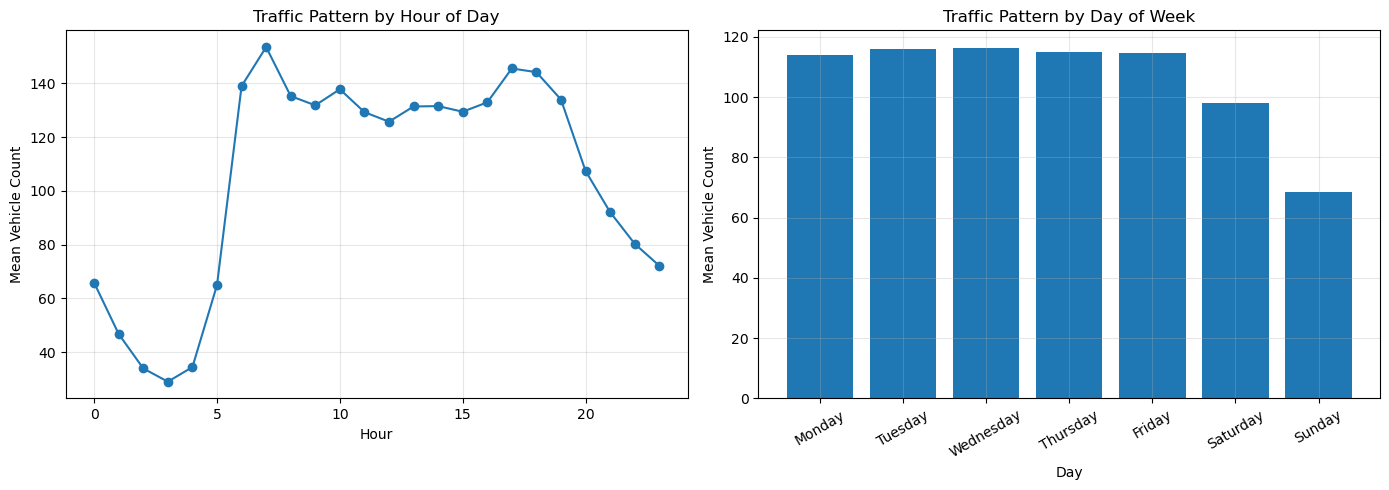

(   hour  mean_hourly_vehicles
 0     0             65.775056
 1     1             46.687459
 2     2             33.893954
 3     3             28.967420
 4     4             34.406785,
   day_of_week  mean_daily_vehicles
 1      Monday           114.013784
 5     Tuesday           115.941999
 6   Wednesday           116.393697
 4    Thursday           114.860973
 0      Friday           114.584294
 2    Saturday            98.199555
 3      Sunday            68.432605)

In [83]:
# Step 3: temporal patterns (hour of day and day of week)
hourly_pattern = (
    traffic_df
    .groupby('hour', as_index=False)['NUMBER_OF_VEHICLES']
    .mean()
    .rename(columns={'NUMBER_OF_VEHICLES': 'mean_hourly_vehicles'})
)

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_pattern = (
    traffic_df
    .groupby('day_of_week', as_index=False)['NUMBER_OF_VEHICLES']
    .mean()
    .rename(columns={'NUMBER_OF_VEHICLES': 'mean_daily_vehicles'})
)
daily_pattern['day_of_week'] = pd.Categorical(daily_pattern['day_of_week'], categories=day_order, ordered=True)
daily_pattern = daily_pattern.sort_values('day_of_week')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hourly_pattern['hour'], hourly_pattern['mean_hourly_vehicles'], marker='o')
axes[0].set_title('Traffic Pattern by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Mean Vehicle Count')
axes[0].grid(True, alpha=0.3)

axes[1].bar(daily_pattern['day_of_week'].astype(str), daily_pattern['mean_daily_vehicles'])
axes[1].set_title('Traffic Pattern by Day of Week')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Mean Vehicle Count')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

hourly_pattern.head(), daily_pattern

## 2) Traffic-Based Demand Scoring

To rank station attractiveness, I use a weighted score with three components required by the lab:

- **Volume component**: higher mean daily vehicle count is better
- **Speed component**: lower mean speed is better (congestion/stop-go effect)
- **Consistency component**: locations with stable demand across days are preferred

All components are min-max normalized to `[0, 1]`, then combined:

\[
\text{demand\_score} = 0.50 \cdot \text{volume\_norm} + 0.30 \cdot \text{low\_speed\_norm} + 0.20 \cdot \text{consistency\_norm}
\]

where `consistency_norm` is based on low coefficient of variation of daily traffic (more stable = higher score).

In [84]:
# Step 4: compute demand score

def minmax(series):
    smin, smax = series.min(), series.max()
    if smax == smin:
        return pd.Series(0.0, index=series.index)
    return (series - smin) / (smax - smin)

# Consistency via coefficient of variation (std/mean) on daily sensor totals
consistency_raw = (
    daily_sensor
    .groupby('sensor_id')['daily_vehicles']
    .agg(['mean', 'std'])
    .reset_index()
)
consistency_raw['cv'] = (consistency_raw['std'].fillna(0) / consistency_raw['mean'].replace(0, np.nan)).fillna(0)
consistency_raw = consistency_raw[['sensor_id', 'cv']]

score_df = location_stats.merge(consistency_raw, on='sensor_id', how='left')

score_df['volume_norm'] = minmax(score_df['mean_daily_vehicle_count'])
score_df['low_speed_norm'] = 1 - minmax(score_df['mean_speed'])
score_df['consistency_norm'] = 1 - minmax(score_df['cv'])

score_df['demand_score'] = (
    0.50 * score_df['volume_norm'] +
    0.30 * score_df['low_speed_norm'] +
    0.20 * score_df['consistency_norm']
)

score_ranked = score_df.sort_values('demand_score', ascending=False).reset_index(drop=True)

score_ranked[['sensor_id', 'demand_score', 'mean_daily_vehicle_count', 'mean_speed', 'cv']].head(20)

,sensor_id,demand_score,mean_daily_vehicle_count,mean_speed,cv
0,sxk9vb,0.845503,11342.142857,54.613095,0.201402
1,sxk9ub,0.763462,9882.000000,61.369048,0.187631
2,sxk9ku,0.758987,8179.142857,37.232143,0.186161
3,sxk9s5,0.732852,7619.000000,38.732143,0.166284
4,sxk9u8,0.731964,8938.000000,58.339286,0.178921
5,sxk9sh,0.719865,7232.428571,36.630952,0.180317
6,sxk9v0,0.702172,8976.000000,69.714286,0.167392
7,sxk9v8,0.698995,8746.142857,66.976190,0.174354
8,sxk9v2,0.681041,8480.428571,69.827381,0.160304
9,sxk9m5,0.666856,6539.714286,45.232143,0.162623


## Methodology Formula Summary

### Base variables from the dataset
- `AVERAGE_SPEED`: average speed at a sensor for each hour (km/h)
- `NUMBER_OF_VEHICLES`: vehicle count at a sensor for each hour
- `sensor_id = GEOHASH`

### Aggregated traffic metrics
For each sensor `s`:

- **Mean speed**
\[
\text{mean\_speed}_s = \frac{1}{T_s}\sum_{t=1}^{T_s} \text{AVERAGE\_SPEED}_{s,t}
\]

- **Peak-hour vehicle count**
\[
\text{peak\_hour\_vehicle\_count}_s = \max_t(\text{NUMBER\_OF\_VEHICLES}_{s,t})
\]

- **Total vehicle count**
\[
\text{total\_vehicle\_count}_s = \sum_t \text{NUMBER\_OF\_VEHICLES}_{s,t}
\]

- **Mean daily vehicle count**
  1. Compute daily totals: \(V_{s,d} = \sum_{t \in d} \text{NUMBER\_OF\_VEHICLES}_{s,t}\)
  2. Then average over days:
\[
\text{mean\_daily\_vehicle\_count}_s = \frac{1}{D_s}\sum_{d=1}^{D_s} V_{s,d}
\]

### Consistency metric
- Daily coefficient of variation:
\[
\text{cv}_s = \frac{\sigma(V_{s,d})}{\mu(V_{s,d})}
\]
Lower `cv` means more stable traffic across days.

### Normalization
For any metric \(x\):
\[
\text{norm}(x) = \frac{x - x_{\min}}{x_{\max} - x_{\min}}
\]

We use:
- `volume_norm = norm(mean_daily_vehicle_count)`
- `low_speed_norm = 1 - norm(mean_speed)`
- `consistency_norm = 1 - norm(cv)`

### Demand score
\[
\text{demand\_score} = 0.50\cdot\text{volume\_norm} + 0.30\cdot\text{low\_speed\_norm} + 0.20\cdot\text{consistency\_norm}
\]

### Practical selection filters
Before final ranking, candidates are filtered by:
- **Istanbul bounding box:** `40.80 <= latitude <= 41.35` and `28.40 <= longitude <= 29.80`
- **Minimum activity:** `mean_daily_vehicle_count >= 100`

### Distance stabilization
To prevent extreme outliers from dominating:
\[
\text{distance\_capped\_km} = \min(\text{nearest\_station\_km}, 5.0)
\]
\[
\text{distance\_norm} = \text{norm}(\text{distance\_capped\_km})
\]

### Final underserved score used for site selection
\[
\text{underserved\_score} = 0.75\cdot\text{demand\_score} + 0.25\cdot\text{distance\_norm}
\]

Then exactly 3 points are selected with a spacing rule (`>= 4 km`) so recommendations are not clustered.

## 3) Existing Stations + Nearest Distance

Now we combine demand with market coverage, with practical filters to avoid out-of-scope candidates:

1. Clean/deduplicate existing gas station points
2. Restrict candidate sensors to an Istanbul bounding box (`lat: 40.80-41.35`, `lon: 28.40-29.80`)
3. Compute **nearest existing station distance** for each candidate sensor
4. Build an **underserved score** that rewards high demand and larger nearest-station distance (with distance capping)
5. Apply a minimum traffic threshold so very low-activity locations are excluded

In [85]:
# Step 5: prepare candidate coordinates + existing station coordinates

# Candidate points: unique traffic sensor locations
candidate_coords = (
    traffic_df[['sensor_id', 'LATITUDE', 'LONGITUDE']]
    .drop_duplicates('sensor_id')
    .rename(columns={'LATITUDE': 'latitude', 'LONGITUDE': 'longitude'})
)

# Keep only Istanbul-area candidates (prevents out-of-scope selections)
lat_min, lat_max = 40.80, 41.35
lon_min, lon_max = 28.40, 29.80
candidate_coords = candidate_coords[
    candidate_coords['latitude'].between(lat_min, lat_max)
    & candidate_coords['longitude'].between(lon_min, lon_max)
].reset_index(drop=True)

# Existing stations: keep valid coordinate rows and deduplicate
stations_clean = stations_df.copy()
stations_clean = stations_clean.dropna(subset=['latitude', 'longitude'])
stations_clean['latitude'] = pd.to_numeric(stations_clean['latitude'], errors='coerce')
stations_clean['longitude'] = pd.to_numeric(stations_clean['longitude'], errors='coerce')
stations_clean = stations_clean.dropna(subset=['latitude', 'longitude'])
stations_clean = stations_clean.drop_duplicates(subset=['latitude', 'longitude']).reset_index(drop=True)

print('Candidate sensor points (Istanbul bbox):', len(candidate_coords))
print('Existing station points (cleaned):', len(stations_clean))

Candidate sensor points (Istanbul bbox): 2154
Existing station points (cleaned): 796


In [86]:
# Step 6: nearest existing-station distance (vectorized haversine, km)

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

cand_lat = candidate_coords['latitude'].to_numpy()
cand_lon = candidate_coords['longitude'].to_numpy()
stat_lat = stations_clean['latitude'].to_numpy()
stat_lon = stations_clean['longitude'].to_numpy()

nearest_km = np.empty(len(candidate_coords), dtype=float)

# Chunking keeps memory usage safe for larger distance matrices
chunk_size = 300
for i in range(0, len(candidate_coords), chunk_size):
    j = min(i + chunk_size, len(candidate_coords))
    lat_block = cand_lat[i:j][:, None]
    lon_block = cand_lon[i:j][:, None]
    d = haversine_km(lat_block, lon_block, stat_lat[None, :], stat_lon[None, :])
    nearest_km[i:j] = d.min(axis=1)

candidate_distance = candidate_coords.copy()
candidate_distance['nearest_station_km'] = nearest_km
candidate_distance.head()

,sensor_id,latitude,longitude,nearest_station_km
0,sxk9uv,41.119080,29.042358,0.754864
1,sxk9t7,41.064148,29.064331,1.428856
2,sxk9u8,41.091614,29.031372,1.220615
3,sxk9vg,41.108093,29.086304,1.527760
4,sxk9uu,41.113586,29.042358,0.188450


In [87]:
# Step 7: combine demand + nearest distance and choose exactly 3 sites

selection_df = (
    score_ranked
    .merge(candidate_distance[['sensor_id', 'latitude', 'longitude', 'nearest_station_km']], on='sensor_id', how='inner')
)

# Exclude very low-traffic points (helps avoid unrealistic low-activity picks)
min_mean_daily_vehicles = 100
selection_df = selection_df[selection_df['mean_daily_vehicle_count'] >= min_mean_daily_vehicles].copy()

# Cap distance effect so far-away extremes do not dominate the ranking
distance_cap_km = 5.0
selection_df['distance_capped_km'] = selection_df['nearest_station_km'].clip(upper=distance_cap_km)
selection_df['distance_norm'] = minmax(selection_df['distance_capped_km'])

selection_df['underserved_score'] = 0.75 * selection_df['demand_score'] + 0.25 * selection_df['distance_norm']
selection_df = selection_df.sort_values('underserved_score', ascending=False).reset_index(drop=True)

# Simple spacing rule to avoid selecting 3 very close points
min_spacing_km = 4.0
selected_rows = []
for _, row in selection_df.iterrows():
    if not selected_rows:
        selected_rows.append(row)
    else:
        ok = True
        for s in selected_rows:
            d = haversine_km(row['latitude'], row['longitude'], s['latitude'], s['longitude'])
            if d < min_spacing_km:
                ok = False
                break
        if ok:
            selected_rows.append(row)
    if len(selected_rows) == 3:
        break

final_sites = pd.DataFrame(selected_rows).reset_index(drop=True)

print('Final selected locations (3):')
final_sites[['sensor_id', 'latitude', 'longitude', 'mean_daily_vehicle_count', 'demand_score', 'nearest_station_km', 'underserved_score']]

Final selected locations (3):


,sensor_id,latitude,longitude,mean_daily_vehicle_count,demand_score,nearest_station_km,underserved_score
0,sxk9ub,41.091614,29.042358,9882.000000,0.763462,2.106997,0.677199
1,sxk9ku,41.025696,29.042358,8179.142857,0.758987,0.223697,0.579191
2,sxkdmz,41.217957,29.086304,4459.428571,0.426995,5.078723,0.570246


In [88]:
# Step 8: attach district/neighborhood names (reverse geocoding with safe fallback)
import urllib.parse
import urllib.request
import json
import time

def reverse_geocode_osm(lat, lon):
    base = 'https://nominatim.openstreetmap.org/reverse'
    params = {
        'format': 'jsonv2',
        'lat': float(lat),
        'lon': float(lon),
        'zoom': 14,
        'addressdetails': 1
    }
    url = base + '?' + urllib.parse.urlencode(params)
    req = urllib.request.Request(url, headers={'User-Agent': 'CE49X-lab-agent/1.0'})
    try:
        with urllib.request.urlopen(req, timeout=12) as resp:
            data = json.load(resp)
        addr = data.get('address', {})
        district = addr.get('suburb') or addr.get('town') or addr.get('city_district') or addr.get('county') or 'Unknown'
        neighborhood = addr.get('neighbourhood') or addr.get('quarter') or addr.get('hamlet') or district
        return neighborhood, district
    except Exception:
        return 'Unknown', 'Unknown'

neighborhoods = []
districts = []
for _, r in final_sites.iterrows():
    nbh, dist = reverse_geocode_osm(r['latitude'], r['longitude'])
    neighborhoods.append(nbh)
    districts.append(dist)
    time.sleep(1.0)  # polite rate limit for public API

final_sites['neighborhood'] = neighborhoods
final_sites['district'] = districts

# Final reporting table required by assignment
report_cols = ['sensor_id', 'latitude', 'longitude', 'neighborhood', 'district', 'demand_score', 'nearest_station_km', 'underserved_score']
final_sites_report = final_sites[report_cols].copy()
final_sites_report

,sensor_id,latitude,longitude,neighborhood,district,demand_score,nearest_station_km,underserved_score
0,sxk9ub,41.091614,29.042358,Fatih Sultan Mehmet Mahallesi,Fatih Sultan Mehmet Mahallesi,0.763462,2.106997,0.677199
1,sxk9ku,41.025696,29.042358,Validebağ,Altunizade Mahallesi,0.758987,0.223697,0.579191
2,sxkdmz,41.217957,29.086304,Sarıyer,Sarıyer,0.426995,5.078723,0.570246


## 4) Proposed 3 Locations with Short Justifications

Below is a compact justification for each selected location. The code automatically uses the computed metrics.

- **High demand score** means consistently strong traffic opportunity.
- **Higher nearest-station distance** means weaker existing supply nearby.
- **Underserved score** balances both demand and current coverage.

In [89]:
# Auto-generate 2-3 sentence justifications for each proposed site
justifications = []
for _, r in final_sites_report.iterrows():
    txt = (
        f"This location near {r['neighborhood']} ({r['district']}) was selected because it has a strong demand score "
        f"({r['demand_score']:.3f}) and remains relatively underserved, with the nearest existing station about "
        f"{r['nearest_station_km']:.2f} km away. "
        f"Its combined underserved score ({r['underserved_score']:.3f}) places it among the best candidates for a new station."
    )
    justifications.append(txt)

final_sites_report['justification'] = justifications
final_sites_report

,sensor_id,latitude,longitude,neighborhood,district,demand_score,nearest_station_km,underserved_score,justification
0,sxk9ub,41.091614,29.042358,Fatih Sultan Mehmet Mahallesi,Fatih Sultan Mehmet Mahallesi,0.763462,2.106997,0.677199,This location near Fatih Sultan Mehmet Mahalle...
1,sxk9ku,41.025696,29.042358,Validebağ,Altunizade Mahallesi,0.758987,0.223697,0.579191,This location near Validebağ (Altunizade Mahal...
2,sxkdmz,41.217957,29.086304,Sarıyer,Sarıyer,0.426995,5.078723,0.570246,This location near Sarıyer (Sarıyer) was selec...


## 5) Visualizations

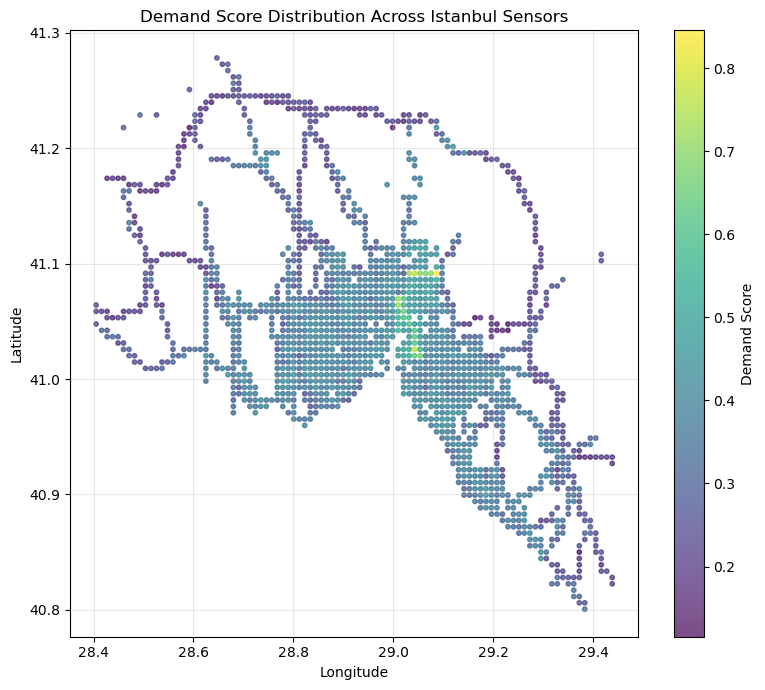

In [90]:
# Visualization 1: demand score scatter map (lat/lon)
viz_demand = selection_df[['latitude', 'longitude', 'demand_score']].copy()

plt.figure(figsize=(8, 7))
sc = plt.scatter(
    viz_demand['longitude'],
    viz_demand['latitude'],
    c=viz_demand['demand_score'],
    cmap='viridis',
    s=10,
    alpha=0.7
)
plt.colorbar(sc, label='Demand Score')
plt.title('Demand Score Distribution Across Istanbul Sensors')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

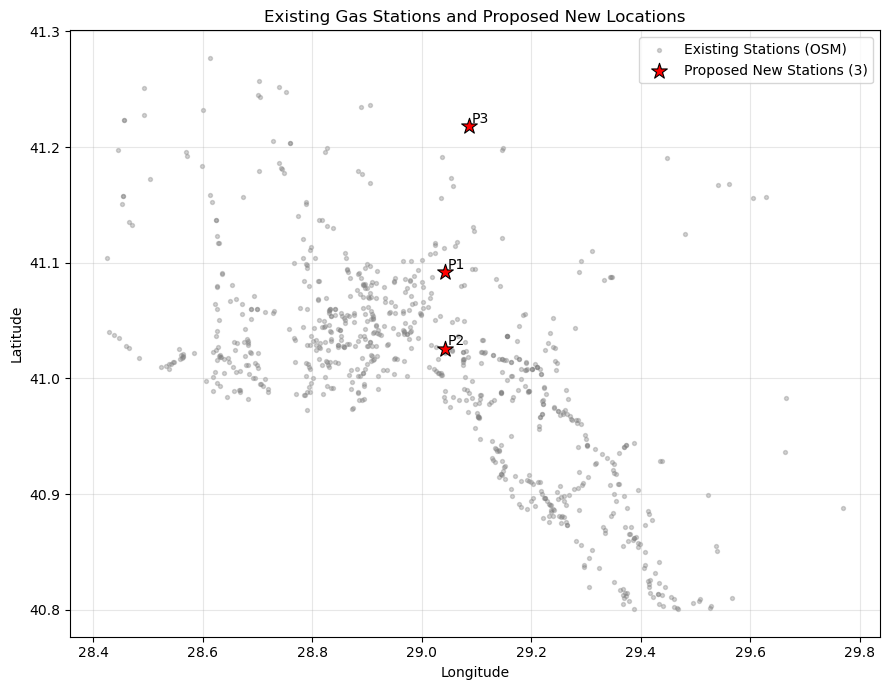

In [91]:
# Visualization 2: existing gas stations + proposed new locations
plt.figure(figsize=(9, 7))

plt.scatter(
    stations_clean['longitude'],
    stations_clean['latitude'],
    s=8,
    alpha=0.35,
    label='Existing Stations (OSM)',
    color='tab:gray'
)

plt.scatter(
    final_sites_report['longitude'],
    final_sites_report['latitude'],
    s=140,
    marker='*',
    color='red',
    edgecolor='black',
    linewidth=0.8,
    label='Proposed New Stations (3)'
)

for i, r in final_sites_report.reset_index(drop=True).iterrows():
    plt.text(r['longitude'] + 0.005, r['latitude'] + 0.003, f"P{i+1}", fontsize=10)

plt.title('Existing Gas Stations and Proposed New Locations')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

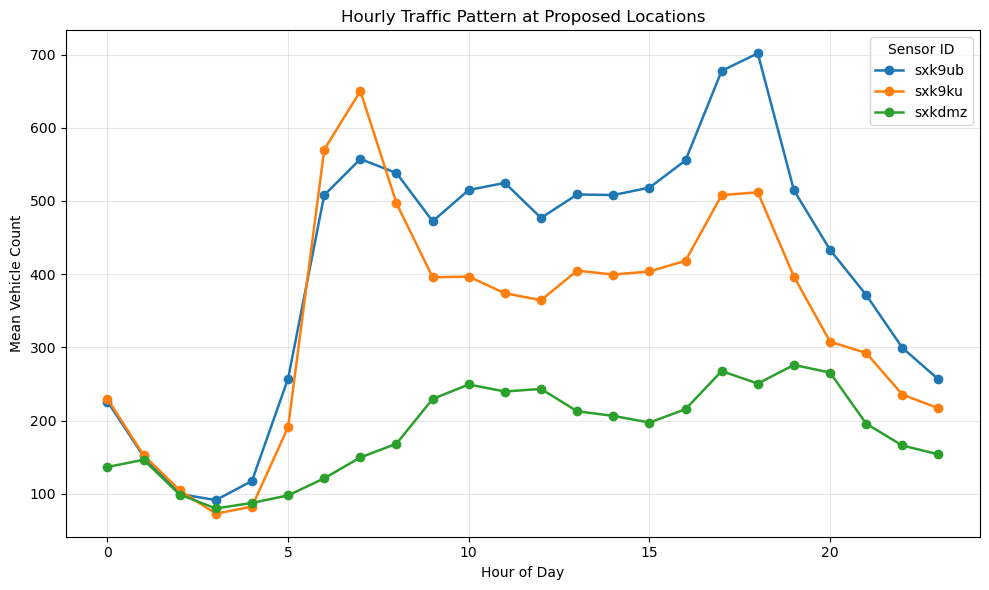

In [92]:
# Visualization 3: hourly traffic profile at the 3 proposed sensor locations
proposed_ids = final_sites_report['sensor_id'].tolist()
proposed_hourly = (
    traffic_df[traffic_df['sensor_id'].isin(proposed_ids)]
    .groupby(['sensor_id', 'hour'], as_index=False)['NUMBER_OF_VEHICLES']
    .mean()
    .rename(columns={'NUMBER_OF_VEHICLES': 'mean_hourly_vehicles'})
)

plt.figure(figsize=(10, 6))
for sid in proposed_ids:
    tmp = proposed_hourly[proposed_hourly['sensor_id'] == sid]
    plt.plot(tmp['hour'], tmp['mean_hourly_vehicles'], marker='o', linewidth=1.8, label=sid)

plt.title('Hourly Traffic Pattern at Proposed Locations')
plt.xlabel('Hour of Day')
plt.ylabel('Mean Vehicle Count')
plt.legend(title='Sensor ID')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5.1) Interactive OSM Map (District + Neighborhood + Coordinates)

This map shows:
- Existing gas stations (gray points)
- Proposed 3 new locations (`P1`, `P2`, `P3`) as colored star markers

For each proposed location, popup text includes district, neighborhood, latitude/longitude, demand score, and nearest existing-station distance.

In [93]:
%pip install folium

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Fallback: save interactive map to HTML and open in browser
import webbrowser

if 'm' not in globals():
    raise RuntimeError("Map object 'm' not found. Run the interactive map cell first.")

map_path = lab_dir / 'istanbul_proposed_sites_map.html'
m.save(str(map_path))
print('Saved map file:', map_path)

# Open with system browser (works even if notebook trust is disabled)
webbrowser.open(map_path.resolve().as_uri())

In [94]:
# Interactive OSM map with cleaner district/neighborhood labels
# If folium is missing, install with: pip install folium
import json
import time
import urllib.parse
import urllib.request

try:
    import folium
except ImportError as e:
    raise ImportError("folium is not installed. Run: pip install folium") from e


def reverse_geocode_admin(lat, lon):
    base = 'https://nominatim.openstreetmap.org/reverse'
    params = {
        'format': 'jsonv2',
        'lat': float(lat),
        'lon': float(lon),
        'zoom': 14,
        'addressdetails': 1
    }
    url = base + '?' + urllib.parse.urlencode(params)
    req = urllib.request.Request(url, headers={'User-Agent': 'CE49X-lab-agent/1.0'})

    try:
        with urllib.request.urlopen(req, timeout=12) as resp:
            data = json.load(resp)
        addr = data.get('address', {})

        # Prefer district-like labels used in Istanbul
        district = (
            addr.get('city_district')
            or addr.get('town')
            or addr.get('municipality')
            or addr.get('county')
            or addr.get('suburb')
            or 'Unknown'
        )

        neighborhood = (
            addr.get('suburb')
            or addr.get('neighbourhood')
            or addr.get('quarter')
            or addr.get('village')
            or addr.get('hamlet')
            or 'Unknown'
        )

        return neighborhood, district
    except Exception:
        return 'Unknown', 'Unknown'


# Refresh admin labels specifically for final 3 points
new_neighborhoods = []
new_districts = []
for _, r in final_sites_report.iterrows():
    nbh, dist = reverse_geocode_admin(r['latitude'], r['longitude'])
    new_neighborhoods.append(nbh)
    new_districts.append(dist)
    time.sleep(1.0)

final_sites_report['neighborhood'] = new_neighborhoods
final_sites_report['district'] = new_districts

# Save updated final table
final_sites_report.to_csv(lab_dir / 'proposed_new_gas_station_locations.csv', index=False)

# Build Istanbul-centered map
center_lat = final_sites_report['latitude'].mean()
center_lon = final_sites_report['longitude'].mean()
m = folium.Map(location=[center_lat, center_lon], zoom_start=11, tiles='OpenStreetMap')

# Add existing stations (sample to keep map responsive)
stations_plot = stations_clean[['latitude', 'longitude']].copy()
if len(stations_plot) > 500:
    stations_plot = stations_plot.sample(500, random_state=42)

for _, row in stations_plot.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=2,
        color='#808080',
        fill=True,
        fill_opacity=0.35,
        weight=0
    ).add_to(m)

colors = ['red', 'blue', 'green']
for i, (_, r) in enumerate(final_sites_report.reset_index(drop=True).iterrows()):
    popup_html = f"""
    <b>P{i+1} - Proposed New Station</b><br>
    District: {r['district']}<br>
    Neighborhood: {r['neighborhood']}<br>
    Latitude: {r['latitude']:.6f}<br>
    Longitude: {r['longitude']:.6f}<br>
    Demand Score: {r['demand_score']:.3f}<br>
    Nearest Existing Station: {r['nearest_station_km']:.2f} km
    """

    folium.Marker(
        location=[r['latitude'], r['longitude']],
        popup=folium.Popup(popup_html, max_width=320),
        tooltip=f"P{i+1}: {r['district']} / {r['neighborhood']}",
        icon=folium.Icon(color=colors[i % len(colors)], icon='star')
    ).add_to(m)

# Quick text table for report readability
display(final_sites_report[['sensor_id', 'district', 'neighborhood', 'latitude', 'longitude', 'demand_score', 'nearest_station_km']])

m

,sensor_id,district,neighborhood,latitude,longitude,demand_score,nearest_station_km
0,sxk9ub,Sarıyer,Fatih Sultan Mehmet Mahallesi,41.091614,29.042358,0.763462,2.106997
1,sxk9ku,Üsküdar,Altunizade Mahallesi,41.025696,29.042358,0.758987,0.223697
2,sxkdmz,Sarıyer,Rumelifeneri Mahallesi,41.217957,29.086304,0.426995,5.078723


## 6) Discussion

The three recommended locations were selected by combining two objectives: strong traffic demand and weak nearby station coverage. Demand was quantified using vehicle volume, low average speed, and consistency across days. Then, each candidate sensor was penalized or rewarded based on distance to the nearest existing gas station, so high-demand areas that are already saturated were deprioritized.

Compared with other high-demand points, the selected three locations achieve a better balance between opportunity and service gap. The spacing rule used during final selection also avoids choosing points that are too close to each other, which improves practical network coverage for a company opening multiple sites.

This analysis is intentionally traffic-focused, so it has important limitations. A real investment decision should also include land cost/availability, zoning permissions, road hierarchy and turning access, competition intensity by brand and pricing, environmental constraints, and financial feasibility. If one additional dataset were available, parcel-level land-use and zoning constraints would likely provide the biggest improvement by converting traffic opportunity into truly buildable candidate sites.

In [95]:
# Optional: save final recommended locations table
output_path = lab_dir / 'proposed_new_gas_station_locations.csv'
final_sites_report.to_csv(output_path, index=False)
print('Saved:', output_path)

Saved: C:\Users\alp5k\CE49X\Week03_NumPy_Pandas\lab\proposed_new_gas_station_locations.csv


---

### Questions?

**Dr. Eyuphan Koc**  
eyuphan.koc@bogazici.edu.tr

## Interactive Map Preview (GitHub-safe)

GitHub notebook preview does not run Folium JavaScript, so the live map may not render inside this `.ipynb`.

Static preview screenshot:

![Interactive map preview](map_preview_github.png)

Live interactive version:
- Local HTML: `istanbul_proposed_sites_map.html`
- Online viewer: `https://htmlpreview.github.io/?https://raw.githubusercontent.com/aaadidu/CE49X/main/Week03_NumPy_Pandas/lab/istanbul_proposed_sites_map.html`